# Notebook 4: Matrix Factorization Baseline

En este notebook se implementa un baseline de factorización matricial usando SVD de `Surprise`.
Se evaluará el desempeño sobre los conjuntos de entrenamiento y prueba generados en el notebook 0.

In [3]:
import pandas as pd
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy
from pathlib import Path

# Carga de datos procesados

Se emplean los CSV generados en el notebook 0:
- `ratings.csv`
- `users.csv`
- `movies.csv`

In [4]:
data_path = Path("../data/processed")

ratings = pd.read_csv(data_path / "ratings.csv")
users = pd.read_csv(data_path / "users.csv")
movies = pd.read_csv(data_path / "movies.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


# Preparación de datos para Surprise

In [5]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Entrenamiento de modelo SVD

In [6]:
svd = SVD(random_state=42)
svd.fit(trainset)
predictions = svd.test(testset)

# Evaluación

In [7]:
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)
print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")

RMSE: 0.8729
MAE:  0.6845
RMSE: 0.8729, MAE: 0.6845


Este modelo servirá como baseline para comparar futuras técnicas de factorización y recomendaciones híbridas.

---
# Variantes energéticas SVD con diferentes n_factors

## Objetivo:
Evaluar el impacto de la dimensión latente (n_factors) en:
- **Precisión predictiva** (RMSE, MAE)
- **Consumo energético** (emisiones CO₂)
- **Complejidad del modelo** (número de parámetros)

## Configuración:
- **n_factors**: 20, 50, 100 (menor dimensión = menos parámetros)
- **Fracciones del dataset**: 25%, 50%, 75%
- **n_epochs**: 20 (fijo)
- **learning rate**: 0.005 (fijo)

## Hipótesis:
- Menor n_factors → Menos parámetros → Menor consumo energético
- ¿Trade-off con la capacidad de representación y precisión?

In [8]:
from codecarbon import EmissionsTracker
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Cargar conjunto de test (fijo para todos los experimentos)

In [9]:
test = pd.read_csv(data_path / "test.csv")
print(f"Test set: {len(test)} ratings")

Test set: 6040 ratings


## Experimentos con diferentes n_factors

In [ ]:
results_svd_variants = []

n_factors_values = [20, 50, 100]
fractions = [25, 50, 75]

N_EPOCHS = 20
LEARNING_RATE = 0.005
RANDOM_STATE = 42

print("="*70)
print("EXPERIMENTOS: Variantes energéticas SVD")
print("="*70)
print(f"Total experimentos: {len(n_factors_values) * len(fractions)}")
print(f"n_epochs: {N_EPOCHS}, lr: {LEARNING_RATE}")
print()

experiment_count = 0

for n_factors in n_factors_values:
    for fraction in fractions:
        experiment_count += 1
        
        print(f"\n{'='*70}")
        print(f"EXPERIMENTO {experiment_count}/{len(n_factors_values)*len(fractions)}")
        print(f"SVD: n_factors={n_factors}, fracción={fraction}%")
        print('='*70)
        
        train_file = data_path / "subsampled_informed" / f"ratings_top_items_{fraction}.csv"
        
        if not train_file.exists():
            print(f"ADVERTENCIA: {train_file} no existe")
            continue
        
        train_frac = pd.read_csv(train_file)
        print(f"Dataset cargado: {len(train_frac)} ratings")
        
        reader = Reader(rating_scale=(1, 5))
        data = Dataset.load_from_df(
            train_frac[['userId', 'movieId', 'rating']], reader
        )
        trainset = data.build_full_trainset()
        
        model = SVD(
            n_factors=n_factors,
            n_epochs=N_EPOCHS,
            lr_all=LEARNING_RATE,
            random_state=RANDOM_STATE,
            verbose=False
        )
        
        tracker = EmissionsTracker(
            project_name=f"SVD_f{n_factors}_fr{fraction}",
            output_dir="../results",
            log_level="error"
        )
        tracker.start()
        
        print("Entrenando modelo...")
        model.fit(trainset)
        
        print("Generando predicciones...")
        testset_frac = list(zip(test['userId'], test['movieId'], test['rating']))
        predictions = model.test(testset_frac)
        
        emissions = tracker.stop()
        
        actuals = [pred.r_ui for pred in predictions]
        preds = [pred.est for pred in predictions]
        
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mae = mean_absolute_error(actuals, preds)
        
        n_users = train_frac['userId'].nunique()
        n_items = train_frac['movieId'].nunique()
        n_params = n_factors * (n_users + n_items) + n_users + n_items + 1
        
        results_svd_variants.append({
            'method': f'SVD_f{n_factors}',
            'n_factors': n_factors,
            'fraction': fraction,
            'rmse': rmse,
            'mae': mae,
            'emissions_kg': emissions,
            'n_params': n_params,
            'train_size': len(train_frac),
            'n_users': n_users,
            'n_items': n_items
        })
        
        print(f"\n RESULTADOS:")
        print(f"   RMSE: {rmse:.4f}")
        print(f"   MAE:  {mae:.4f}")
        print(f"   CO2:  {emissions:.6f} kg ({emissions*1000:.3f} g)")
        print(f"   Parámetros: {n_params:,}")

print(f"\n{'='*70}")
print(f"EXPERIMENTOS COMPLETADOS: {len(results_svd_variants)}/{len(n_factors_values)*len(fractions)}")
print('='*70)

EXPERIMENTOS: Variantes energéticas SVD
Total experimentos: 9
n_epochs: 20, lr: 0.005


EXPERIMENTO 1/9
SVD: n_factors=20, fracción=25%
Dataset cargado: 723075 ratings
Entrenando modelo...
Generando predicciones...

 RESULTADOS:
   RMSE: 0.9992
   MAE:  0.7761
   CO2:  0.000021 kg (0.021 g)
   Parámetros: 146,287

EXPERIMENTO 2/9
SVD: n_factors=20, fracción=50%
Dataset cargado: 923889 ratings
Entrenando modelo...
Generando predicciones...

 RESULTADOS:
   RMSE: 0.8892
   MAE:  0.6980
   CO2:  0.000037 kg (0.037 g)
   Parámetros: 165,754

EXPERIMENTO 3/9
SVD: n_factors=20, fracción=75%
Dataset cargado: 988678 ratings
Entrenando modelo...
Generando predicciones...

 RESULTADOS:
   RMSE: 0.8502
   MAE:  0.6728
   CO2:  0.000047 kg (0.047 g)
   Parámetros: 185,200

EXPERIMENTO 4/9
SVD: n_factors=50, fracción=25%
Dataset cargado: 723075 ratings
Entrenando modelo...
Generando predicciones...

 RESULTADOS:
   RMSE: 0.9657
   MAE:  0.7426
   CO2:  0.000030 kg (0.030 g)
   Parámetros: 355,267



## Guardar resultados de variantes energéticas

In [12]:
if len(results_svd_variants) > 0:
    df_svd_variants = pd.DataFrame(results_svd_variants)
    df_svd_variants = df_svd_variants.sort_values(['n_factors', 'fraction'])
    
    output_file = Path("../results/svd_energy_variants.csv")
    df_svd_variants.to_csv(output_file, index=False)
    
    print(f"\n Resultados guardados en: {output_file}")
    print(f"\nResumen:")
    print(df_svd_variants[[
        'method', 'n_factors', 'fraction', 'rmse', 'mae', 'emissions_kg', 'n_params'
    ]].to_string(index=False))
else:
    print("\n No hay resultados para guardar")


 Resultados guardados en: ..\results\svd_energy_variants.csv

Resumen:
  method  n_factors  fraction     rmse      mae  emissions_kg  n_params
 SVD_f20         20        25 0.999165 0.776104      0.000021    146287
 SVD_f20         20        50 0.889207 0.697952      0.000037    165754
 SVD_f20         20        75 0.850195 0.672843      0.000047    185200
 SVD_f50         50        25 0.965691 0.742633      0.000030    355267
 SVD_f50         50        50 0.836038 0.653831      0.000043    402544
 SVD_f50         50        75 0.789745 0.623089      0.000064    449770
SVD_f100        100        25 0.926134 0.701078      0.000064    703567
SVD_f100        100        50 0.775379 0.600025      0.000078    797194
SVD_f100        100        75 0.715617 0.565181      0.000080    890720


## Análisis preliminar: impacto de n_factors


 Gráfico guardado en results/svd_factors_impact.png


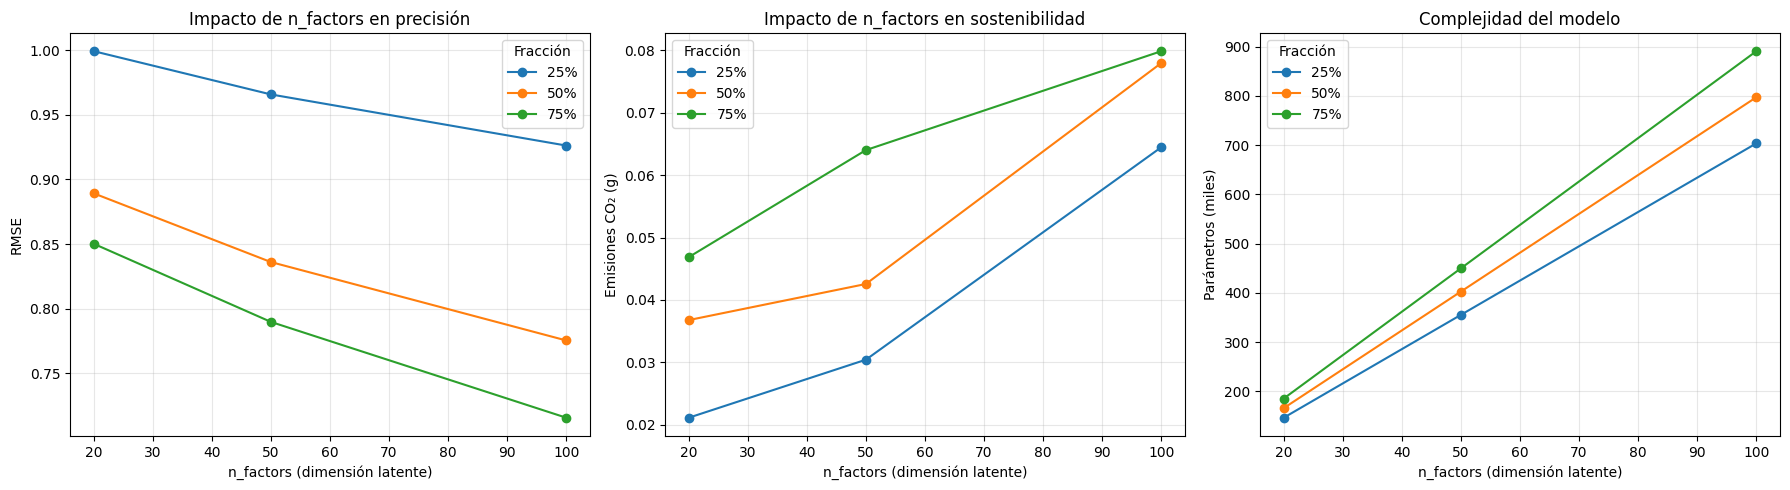

In [13]:
if len(results_svd_variants) > 0:
    import matplotlib.pyplot as plt
    
    df_svd_variants = pd.DataFrame(results_svd_variants)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for fraction in df_svd_variants['fraction'].unique():
        data = df_svd_variants[df_svd_variants['fraction'] == fraction]
        axes[0].plot(data['n_factors'], data['rmse'], marker='o', label=f'{fraction}%')
    
    axes[0].set_xlabel('n_factors (dimensión latente)')
    axes[0].set_ylabel('RMSE')
    axes[0].set_title('Impacto de n_factors en precisión')
    axes[0].legend(title='Fracción')
    axes[0].grid(alpha=0.3)
    
    for fraction in df_svd_variants['fraction'].unique():
        data = df_svd_variants[df_svd_variants['fraction'] == fraction]
        axes[1].plot(data['n_factors'], data['emissions_kg']*1000, marker='o', label=f'{fraction}%')
    
    axes[1].set_xlabel('n_factors (dimensión latente)')
    axes[1].set_ylabel('Emisiones CO₂ (g)')
    axes[1].set_title('Impacto de n_factors en sostenibilidad')
    axes[1].legend(title='Fracción')
    axes[1].grid(alpha=0.3)
    
    for fraction in df_svd_variants['fraction'].unique():
        data = df_svd_variants[df_svd_variants['fraction'] == fraction]
        axes[2].plot(data['n_factors'], data['n_params']/1000, marker='o', label=f'{fraction}%')
    
    axes[2].set_xlabel('n_factors (dimensión latente)')
    axes[2].set_ylabel('Parámetros (miles)')
    axes[2].set_title('Complejidad del modelo')
    axes[2].legend(title='Fracción')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/svd_factors_impact.png', dpi=150, bbox_inches='tight')
    print("\n Gráfico guardado en results/svd_factors_impact.png")
    plt.show()
else:
    print("No hay suficientes datos para análisis")

## Conclusiones preliminares

### Observaciones esperadas:

1. **Trade-off dimensión-precisión**:
   - Mayor n_factors → Mayor capacidad de representación
   - Pero también más parámetros y mayor consumo

2. **Escalabilidad**:
   - El número de parámetros crece linealmente con n_factors
   - Impacto directo en tiempo de entrenamiento y consumo energético

3. **Comparación con NCF**:
   - SVD típicamente más eficiente que NCF
   - Pero con menor capacidad de modelar interacciones no lineales